In [ ]:
!pip install kaggle opencv-python torch torchvision scikit-learn tqdm


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"dennisphilip","key":"b1f107aaf36c96802d8b060ccb8bf489"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d aryashah2k/ucsd-pedestrian-database
!unzip ucsd-pedestrian-database.zip -d ucsd


Streaming output truncated to the last 5000 lines.
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f076.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f077.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f078.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f079.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f080.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f081.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f082.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f083.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f084.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f085.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f086.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f087.png  
  inflating: ucsd/ucsdpeds/vidf/vidf6_33_003.y/vidf6_33_003_f088.png  
  inflating: ucsd/ucsdpeds

In [ ]:
import os
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as T

from tqdm import tqdm
from sklearn.metrics import roc_auc_score


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet = resnet.to(device)
resnet.eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225])
])


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def compute_flow(prev, curr):
    return cv2.calcOpticalFlowFarneback(
        prev, curr,
        None, 0.5, 3, 15, 3, 5, 1.2, 0
    )


In [ ]:
@torch.no_grad()
def extract_features(frames):
    features = []
    prev_gray = None

    for frame in frames:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is None:
            flow = np.zeros((frame.shape[0], frame.shape[1], 2), dtype=np.float32)
        else:
            flow = compute_flow(prev_gray, gray).astype(np.float32)

        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        flow_map = np.stack(
            [mag, np.cos(ang), np.sin(ang)],
            axis=-1
        ).astype(np.float32)

        flow_map = cv2.resize(flow_map, (224, 224))
        flow_tensor = torch.from_numpy(flow_map).permute(2, 0, 1)

        rgb_tensor = transform(frame)  # already float32

        x = torch.cat([rgb_tensor, flow_tensor], dim=0)
        x = x.unsqueeze(0).to(device).float()  # 🔑 FORCE float32

        feat = resnet(x[:, :3])
        features.append(feat.cpu().numpy())

        prev_gray = gray

    return np.vstack(features)


In [ ]:
def load_clip(folder):
    frames = []
    for f in sorted(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, f))
        frames.append(img)
    return frames


In [ ]:
!pip install kagglehub


In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "karthiknm1/ucsd-anomaly-detection-dataset"
)

print(path)


100%|██████████| 702M/702M [00:08<00:00, 86.9MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/karthiknm1/ucsd-anomaly-detection-dataset/versions/1


In [ ]:
!kaggle datasets download -d karthiknm1/ucsd-anomaly-detection-dataset
!unzip ucsd-anomaly-detection-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/043.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/044.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/045.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/046.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/047.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/048.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/049.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/050.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/051.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/052.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/053.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/054.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_

In [ ]:
train_root = "UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train"
train_feats = []

for clip in tqdm(sorted(os.listdir(train_root)), desc="Train clips"):
    frames = load_clip(os.path.join(train_root, clip))
    feats = extract_features(frames)
    train_feats.append(feats)

train_feats = np.concatenate(train_feats)
print("Train features shape:", train_feats.shape)


Train clips: 100%|██████████| 16/16 [01:34<00:00,  5.92s/it]

Train features shape: (2550, 512)


In [ ]:
class LSTMA(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.lstm = nn.LSTM(d, 256, batch_first=True)
        self.fc = nn.Linear(256, d)

    def forward(self, x):
        y, _ = self.lstm(x)
        return self.fc(y)


In [ ]:
model = LSTMA(train_feats.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X = torch.tensor(train_feats[:-1]).unsqueeze(0).to(device)
Y = torch.tensor(train_feats[1:]).unsqueeze(0).to(device)

for epoch in range(20):
    pred = model(X)
    loss = criterion(pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.6f}")


Epoch 01 | Loss: 1.354774
Epoch 02 | Loss: 1.133621
Epoch 03 | Loss: 0.973374
Epoch 04 | Loss: 0.822240
Epoch 05 | Loss: 0.681482
Epoch 06 | Loss: 0.558773
Epoch 07 | Loss: 0.459393
Epoch 08 | Loss: 0.382445
Epoch 09 | Loss: 0.323822
Epoch 10 | Loss: 0.278884
Epoch 11 | Loss: 0.243770
Epoch 12 | Loss: 0.216032
Epoch 13 | Loss: 0.194171
Epoch 14 | Loss: 0.177039
Epoch 15 | Loss: 0.163687
Epoch 16 | Loss: 0.153382
Epoch 17 | Loss: 0.145571
Epoch 18 | Loss: 0.139714
Epoch 19 | Loss: 0.135145
Epoch 20 | Loss: 0.131303


In [ ]:
test_root = "UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test"
scores = []

test_clips = sorted([
    d for d in os.listdir(test_root)
    if os.path.isdir(os.path.join(test_root, d))
    and not d.endswith("_gt")
    and not d.startswith(".")
])

print("Found test clips:", test_clips)

model.eval()
with torch.no_grad():
    for clip in tqdm(test_clips, desc="Test clips"):
        clip_path = os.path.join(test_root, clip)

        frames = load_clip(clip_path)
        feats = extract_features(frames)

        x = torch.tensor(feats[:-1]).unsqueeze(0).to(device).float()
        y = torch.tensor(feats[1:]).unsqueeze(0).to(device).float()

        pred = model(x)
        err = ((pred - y) ** 2).mean(dim=2).cpu().numpy().flatten()
        scores.extend(err)

scores = np.array(scores)
print("Total test frames:", len(scores))


Found test clips: ['Test001', 'Test002', 'Test003', 'Test004', 'Test005', 'Test006', 'Test007', 'Test008', 'Test009', 'Test010', 'Test011', 'Test012']


Test clips: 100%|██████████| 12/12 [01:08<00:00,  5.74s/it]

Total test frames: 1998


In [ ]:
gt_all = []

for clip in test_clips:
    gt_folder = os.path.join(
        "UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test",
        f"{clip}_gt"
    )

    gt_frames = sorted([
        f for f in os.listdir(gt_folder)
        if f.endswith(".bmp")
    ])

    if len(gt_frames) == 0:
        raise RuntimeError(f"No GT frames found in {gt_folder}")

    clip_gt = []

    for f in gt_frames:
        mask = cv2.imread(os.path.join(gt_folder, f), cv2.IMREAD_GRAYSCALE)

        # UCSD convention: any white pixel = anomaly
        label = 1 if mask.max() > 0 else 0
        clip_gt.append(label)

    gt_all.append(np.array(clip_gt))

gt = np.concatenate(gt_all)
gt = gt[:len(scores)]  # safety crop

print("GT frames:", len(gt))
print("Score frames:", len(scores))


GT frames: 1998
Score frames: 1998


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(gt, scores)
print("ROC–AUC:", auc)


ROC–AUC: 0.6380979075767605


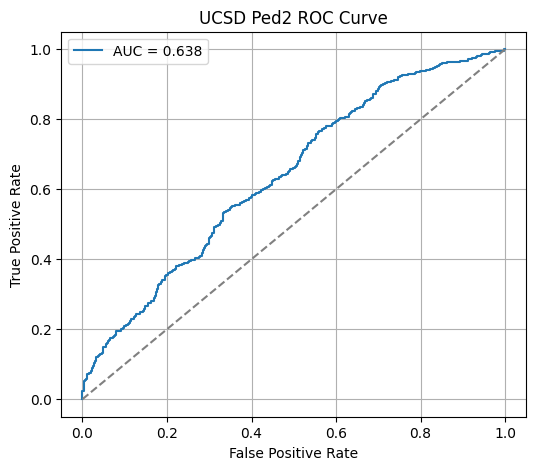

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(gt, scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("UCSD Ped2 ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def temporal_smooth(scores, window=7):
    pad = window // 2
    padded = np.pad(scores, (pad, pad), mode='edge')
    smoothed = np.convolve(padded, np.ones(window)/window, mode='valid')
    return smoothed

scores_smooth = temporal_smooth(scores, window=7)

In [ ]:
class RLThresholdAgent:
    def __init__(self, init_thresh, alpha=0.01):
        self.thresh = init_thresh
        self.alpha = alpha

    def step(self, score):
        # reward: encourage separation
        reward = score - self.thresh
        self.thresh += self.alpha * reward
        return self.thresh


In [ ]:
agent = RLThresholdAgent(
    init_thresh=np.mean(scores_smooth),
    alpha=0.01
)

rl_preds = []
rl_thresh_trace = []

for s in scores_smooth:
    t = agent.step(s)
    rl_thresh_trace.append(t)
    rl_preds.append(1 if s > t else 0)

rl_preds = np.array(rl_preds)
rl_thresh_trace = np.array(rl_thresh_trace)


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

metrics_ucsd = {
    "AUC_raw": roc_auc_score(gt, scores),
    "AUC_smoothed": roc_auc_score(gt, scores_smooth),
    "F1_RL": f1_score(gt, rl_preds),
    "Precision_RL": precision_score(gt, rl_preds),
    "Recall_RL": recall_score(gt, rl_preds)
}

metrics_ucsd


{'AUC_raw': np.float64(0.6380979075767605),
 'AUC_smoothed': np.float64(0.649267516783963),
 'F1_RL': 0.6428571428571429,
 'Precision_RL': 0.916289592760181,
 'Recall_RL': 0.49511002444987773}

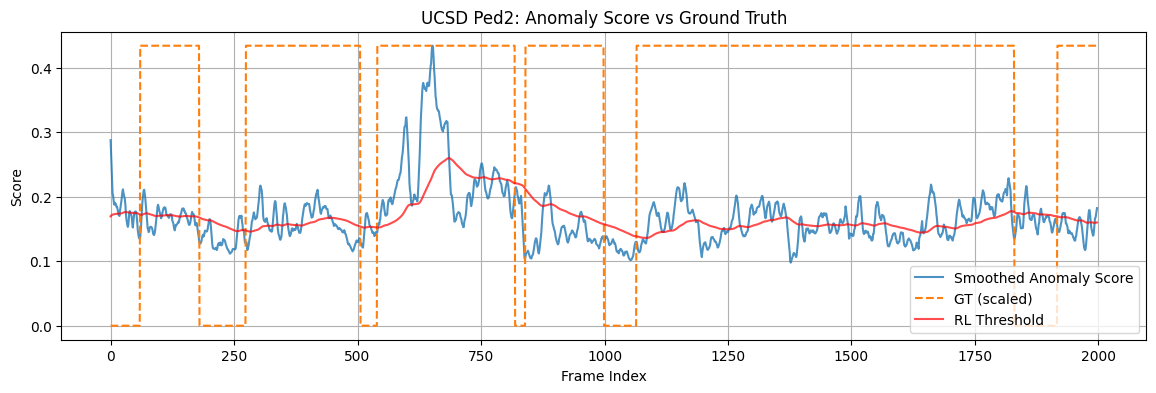

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(scores_smooth, label="Smoothed Anomaly Score", alpha=0.8)
plt.plot(gt * max(scores_smooth), label="GT (scaled)", linestyle='--')
plt.plot(rl_thresh_trace, label="RL Threshold", color='red', alpha=0.7)

plt.title("UCSD Ped2: Anomaly Score vs Ground Truth")
plt.xlabel("Frame Index")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()
